In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = pd.read_csv(r"D:\jupyter\amazon_sales_dataset.csv")

data.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [15]:
data.info()
data.describe()
data.columns

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 5.0 MB


Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='str')

In [16]:
data.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [17]:
data = data.dropna()

In [18]:
data = data.drop_duplicates()

In [20]:
data['order_date'] = pd.to_datetime(data['order_date'])

In [21]:
daily_sales = data.groupby('order_date')['total_revenue'].sum()

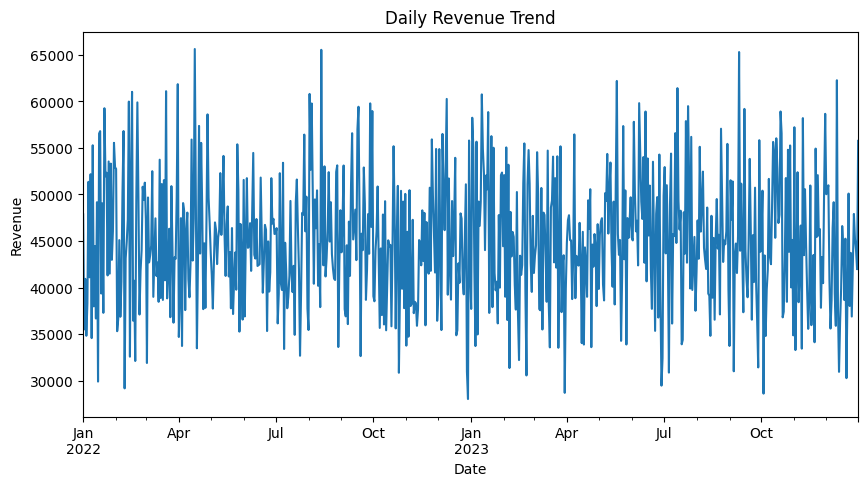

In [22]:
plt.figure(figsize=(10,5))
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

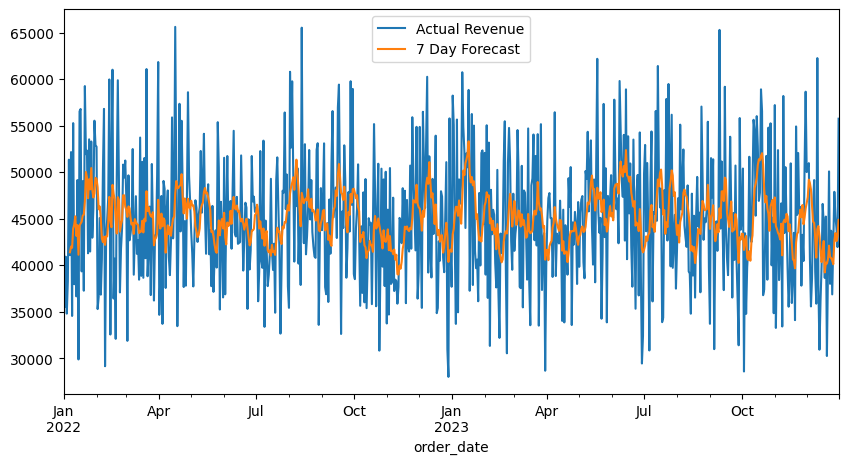

In [23]:
forecast = daily_sales.rolling(7).mean()

plt.figure(figsize=(10,5))
daily_sales.plot(label="Actual Revenue")
forecast.plot(label="7 Day Forecast")
plt.legend()
plt.show()

In [24]:
category_sales = data.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

In [25]:
abc = category_sales.reset_index()
abc.columns = ['product_category','total_revenue']

In [26]:
abc['cumulative_sales'] = abc['total_revenue'].cumsum()
abc['cumulative_percent'] = abc['cumulative_sales'] / abc['total_revenue'].sum()

In [27]:
def category(x):
    if x <= 0.7:
        return 'A'
    elif x <= 0.9:
        return 'B'
    else:
        return 'C'

abc['ABC_Category'] = abc['cumulative_percent'].apply(category)

abc

,product_category,total_revenue,cumulative_sales,cumulative_percent,ABC_Category
0,Beauty,5550624.97,5550624.97,0.168884,A
1,Books,5484863.03,11035488.00,0.335766,A
2,Fashion,5480123.34,16515611.34,0.502505,A
3,Home & Kitchen,5473132.55,21988743.89,0.669031,A
4,Electronics,5470594.03,27459337.92,0.835479,B
5,Sports,5407235.82,32866573.74,1.000000,C


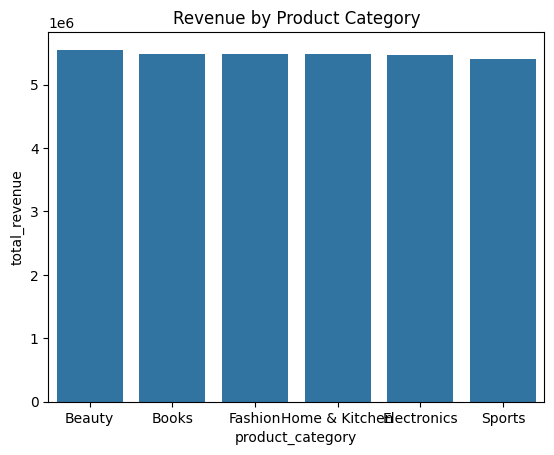

In [28]:
sns.barplot(x='product_category', y='total_revenue', data=abc)
plt.title("Revenue by Product Category")
plt.show()

In [29]:
D = data['quantity_sold'].sum()
S = 50
H = 5

EOQ = np.sqrt((2 * D * S) / H)

print("Economic Order Quantity:", EOQ)

Economic Order Quantity: 1731.8775938270003


In [30]:
daily_demand = data.groupby('order_date')['quantity_sold'].sum().mean()

In [31]:
lead_time = 5

reorder_point = daily_demand * lead_time

print("Reorder Point:", reorder_point)

Reorder Point: 1027.1917808219177


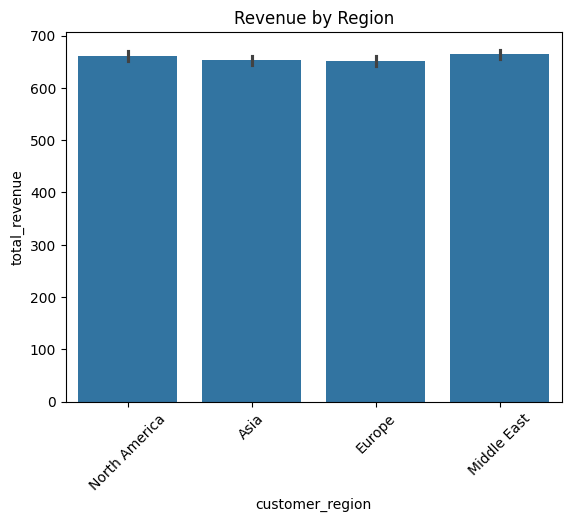

In [32]:
sns.barplot(x='customer_region', y='total_revenue', data=data)
plt.title("Revenue by Region")
plt.xticks(rotation=45)
plt.show()